# Cat vs. Dog Image Classification with PyTorch CNN

## Project Overview

This project focuses on building a Convolutional Neural Network (CNN) from scratch using PyTorch to classify images into two categories: **Cats** and **Dogs**.

The notebook covers the complete image classification pipeline, including:

- Exploring and visualizing the dataset
- Preparing and preprocessing the images
- Building a custom PyTorch Dataset and DataLoader
- Designing and training a CNN model
- Monitoring training and validation performance
- Using Early Stopping and a learning-rate scheduler
- Evaluating the model using Accuracy, Precision, Recall, and F1-score
- Visualizing the Confusion Matrix
- Loading the best-performing model for final predictions
- Visualizing sample predictions on unseen images

### Objective

The main objective is to develop and evaluate a baseline CNN model capable of distinguishing between cat and dog images while demonstrating the complete workflow of an image classification task using PyTorch.

## **Importing libraries**

In [1]:
import torch
import random
import os , cv2
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader ,TensorDataset ,Dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,accuracy_score,precision_score,recall_score,f1_score,classification_report

## **Reading data**

In [2]:
main_path = '/kaggle/input/datasets/kunalgupta2616/dog-vs-cat-images-data/dogcat'
train_data = os.path.join(main_path ,'train')
test_data = os.path.join(main_path ,'test1')
val_data = os.path.join(main_path ,'validation')


# for train data
train_images = []
train_labels = []

for files in os.listdir(train_data):
     print(files)
     files_path = os.path.join(train_data,files)
    
     for image in os.listdir(files_path):
         images = os.path.join(files_path , image)
         train_images.append(images)

         if files == 'cats':
             train_labels.append(0)
         else:
             train_labels.append(1)


# for validation data
val_images = []
val_labels = []

for files_val in os.listdir(val_data):
     files_path_val = os.path.join(val_data,files_val)
    
     for image_val in os.listdir(files_path_val):
         images_val = os.path.join(files_path_val , image_val)
         val_images.append(images_val)

         if files_val == 'cats':
             val_labels.append(0)
         else:
             val_labels.append(1)

dogs
cats


In [3]:
print(f' len of train images is :{len(train_images)} images')
print(f' len of train labels is :{len(train_labels)} labels')
print(f' len of val images is :{len(val_images)} images')
print(f' len of val labels is :{len(val_labels)} labels')

 len of train images is :25000 images
 len of train labels is :25000 labels
 len of val images is :8000 images
 len of val labels is :8000 labels


## **Visualization random sample of train images**

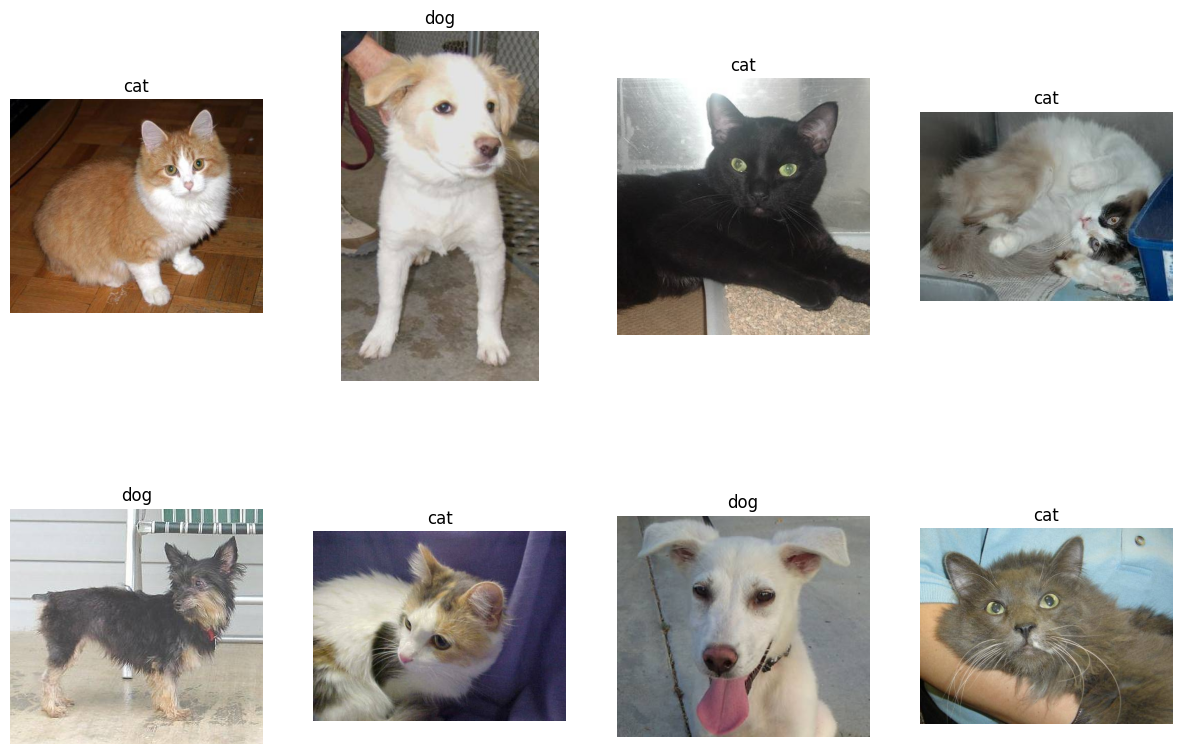

In [4]:
plt.figure(figsize=(15,10))
label_names = {
    0: "cat",
    1: "dog"
}
rand  = random.sample(range(len(train_images)),8)
for i ,idx in enumerate(rand):
    img = cv2.imread(train_images[idx])
    img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(label_names[train_labels[idx]])
    plt.axis('off')
plt.show()

To visualiztion if data is palanced or not by using barplot:

1    12500
0    12500
Name: count, dtype: int64


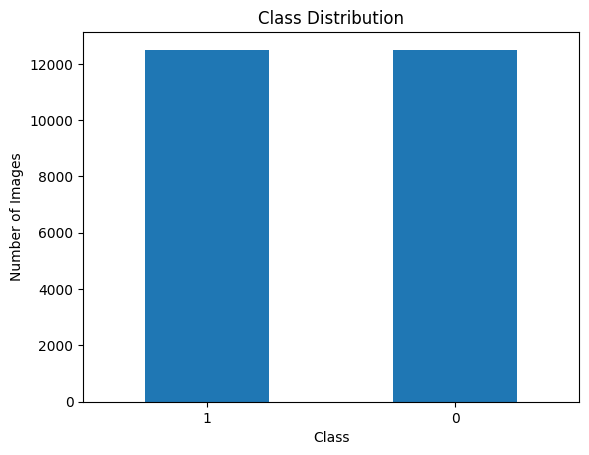

In [5]:
counts = pd.Series(train_labels).value_counts()
print(counts)

counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

## **Custom dataset**

In [6]:
class Animal_Cnn(Dataset):
      def __init__(self,images,labels,transforms= None):
          self.images = images
          self.labels= labels
          self.transforms = transforms

      def __len__(self):
          return len(self.images)

      def __getitem__(self,idx):
          image = Image.open(self.images[idx]).convert('RGB')
          label = self.labels[idx]
          
          if self.transforms :
              image = self.transforms(image)

          return image , label

## **Transforms**

For the baseline model, I used resizing and normalization without data augmentation.

In [7]:
# for train
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        std = [0.229,0.224,0.225],
        mean = [0.485,0.456,0.406]
    )
])
# for val
val_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        std = [0.229,0.224,0.225],
        mean = [0.485,0.456,0.406]
    )
])

## **Buliding dataset**

In [8]:
# train_dataset
train_dataset = Animal_Cnn(
    train_images,
    train_labels,
    transforms = train_transforms
)
# val dataset
val_dataset = Animal_Cnn(
    val_images,
    val_labels,
    transforms = val_transforms
)

## **DataLoader**

In [9]:
BZ = 32
# train
train_loader = DataLoader(
    train_dataset ,
    batch_size = BZ ,
    shuffle = True)
# val data
val_loader = DataLoader(
    val_dataset ,
    batch_size = BZ ,
    shuffle = False)

In [10]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## **Building CNN Model**

we build CNN Model from scratch 

In [11]:
class Animal_CnnModel(nn.Module):
     def __init__(self):
         super().__init__()
         # first conv
         self.conv1 = nn.Conv2d(
             in_channels = 3,
             out_channels = 64,
             kernel_size = 3,
             stride = 1
         )
         # second conv
         self.conv2 = nn.Conv2d(
             in_channels = 64,
             out_channels = 128,
             kernel_size = 3,
             stride = 1
         )
         # Third conv
         self.conv3 = nn.Conv2d(
             in_channels = 128,
             out_channels = 256,
             kernel_size = 3,
             stride = 1
         )
         # maxpooling
         self.pool = nn.MaxPool2d(
             kernel_size = 3,
             stride = 3
         )
         # activation function
         self.relu = nn.ReLU()
         # flatten
         self.flatten = nn.Flatten()

         # fully connected
         self.fc1 = nn.LazyLinear(512)
         self.fc2 = nn.Linear(512,2)

     def forward(self,x):
         x = self.relu(self.conv1(x))
         x = self.pool(x)
         x = self.relu(self.conv2(x))
         x = self.pool(x)
         x = self.relu(self.conv3(x))
         x = self.pool(x)

         x = self.flatten(x)
         x = self.relu(self.fc1(x))
         x = self.fc2(x)
         return x

In [12]:
Animal_CnnModel = Animal_CnnModel()

### **Hyperparameters for model**

we move all data and model to **Cuda**:

In [13]:
device = torch.device("cuda")

Animal_CnnModel = Animal_CnnModel.to(device)
print(f'your device is :{device}')

your device is :cuda


In [14]:
lr = 0.001

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(Animal_CnnModel.parameters(),lr=lr)

# learning rate scadular
scad = scadular = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience=2,
    factor=0.5
)

## **Trainning and Evaluation CNN model**

In [15]:
epochs = 70

patience = 3
counter = 0
best_val_loss = float("inf")

# Lists for plotting
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(epochs):

    # Training
    Animal_CnnModel.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = Animal_CnnModel(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total


    # Validation
    Animal_CnnModel.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = Animal_CnnModel(images)

            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            # Normal prediction using argmax
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    #  Metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Results
    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Acc  : {val_acc:.2f}%")

    print("-" * 50)


    # Early Stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(
            Animal_CnnModel.state_dict(),
            "best_model.pth"
        )

        print("Best model saved.\n")

    else:

        counter += 1

        print(
            f"EarlyStopping Counter: "
            f"{counter}/{patience}\n"
        )

        if counter >= patience:

            print("Early Stopping...")
            break

Epoch [1/70]
Train Loss      : 0.6063
Train Accuracy  : 64.35%
Validation Loss : 0.4413
Validation Acc  : 79.89%
--------------------------------------------------
Best model saved.

Epoch [2/70]
Train Loss      : 0.4087
Train Accuracy  : 81.40%
Validation Loss : 0.3286
Validation Acc  : 85.64%
--------------------------------------------------
Best model saved.

Epoch [3/70]
Train Loss      : 0.3335
Train Accuracy  : 85.47%
Validation Loss : 0.3077
Validation Acc  : 86.29%
--------------------------------------------------
Best model saved.

Epoch [4/70]
Train Loss      : 0.2685
Train Accuracy  : 88.68%
Validation Loss : 0.2206
Validation Acc  : 90.94%
--------------------------------------------------
Best model saved.

Epoch [5/70]
Train Loss      : 0.2218
Train Accuracy  : 90.96%
Validation Loss : 0.1898
Validation Acc  : 92.35%
--------------------------------------------------
Best model saved.

Epoch [6/70]
Train Loss      : 0.1722
Train Accuracy  : 92.86%
Validation Loss : 0.11

### **To visualization train and validation loss**

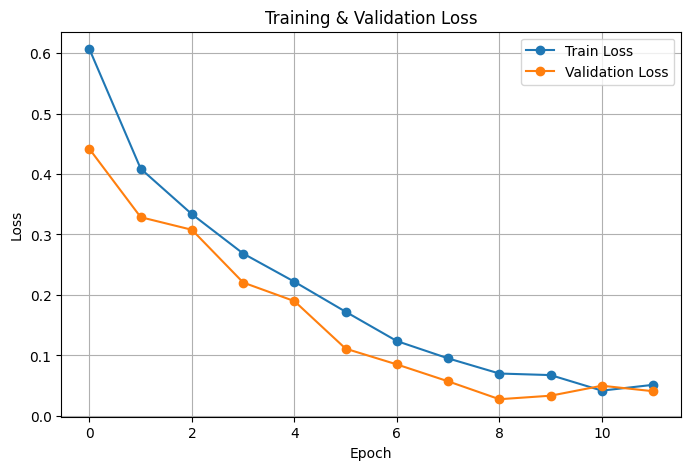

In [16]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### **To visualization train and validation Accuracy**

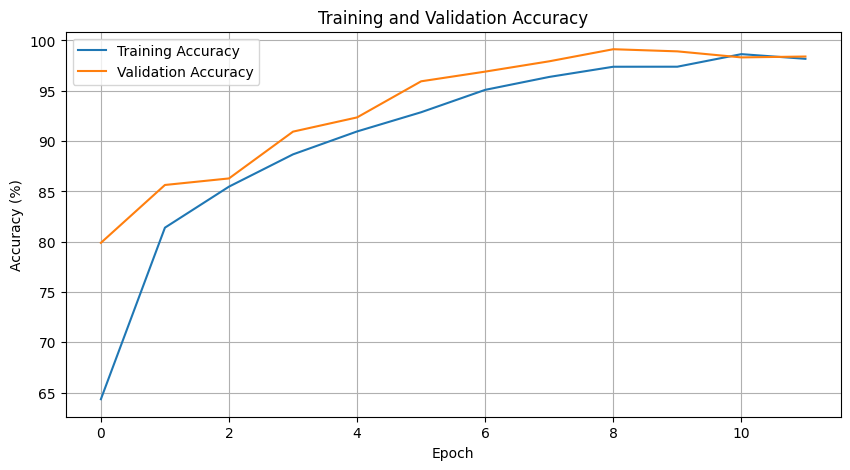

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()
plt.grid(True)

plt.show()

### **Evaluation CNN Model**

In [18]:
Animal_CnnModel.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = Animal_CnnModel(images)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

### **Confusion Matrix**

In [19]:
print(f'Classification report is : \n')
print(classification_report(y_true,y_pred))

Classification report is : 

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4000
           1       0.98      0.99      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



[[3915   85]
 [  43 3957]]
Accuracy : 0.984
Precision: 0.9789708065314201
Recall   : 0.98925
F1 Score : 0.9840835613031584


<Figure size 1500x800 with 0 Axes>

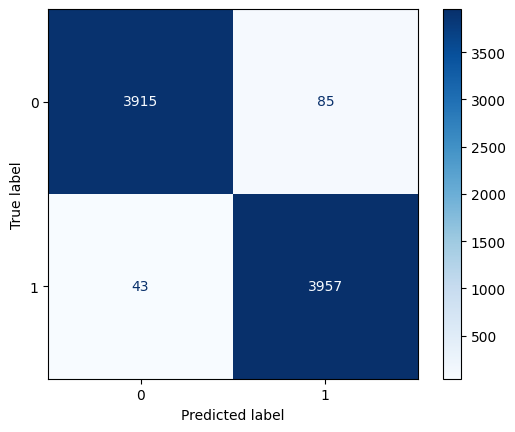

In [20]:
classes = {
    0 :'cats',
    1 : 'dogs'
}
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)
# accuracy
print("Accuracy :", accuracy_score(y_true, y_pred))
# Presion
print("Precision:", precision_score(y_true, y_pred))
# recall
print("Recall   :", recall_score(y_true, y_pred))
# f1
print("F1 Score :", f1_score(y_true, y_pred))

# plot confusion matrix
#  Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)

plt.figure(figsize=(15,8))
disp.plot(cmap="Blues", xticks_rotation=0)
plt.show()

### **Test data**

In [21]:
# To load Best Model
Animal_CnnModel.load_state_dict(torch.load("best_model.pth"))
Animal_CnnModel.eval()

Animal_CnnModel(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

In [22]:
test_images = []

for file in os.listdir(test_data):
    folder_path = os.path.join(test_data,file)
    
    for img in os.listdir(folder_path):
        images_path = os.path.join(folder_path,img)
        test_images.append(images_path)

In [23]:
print(f'len of test images : {len(test_images)} images')

len of test images : 12500 images


Show random images at test data:

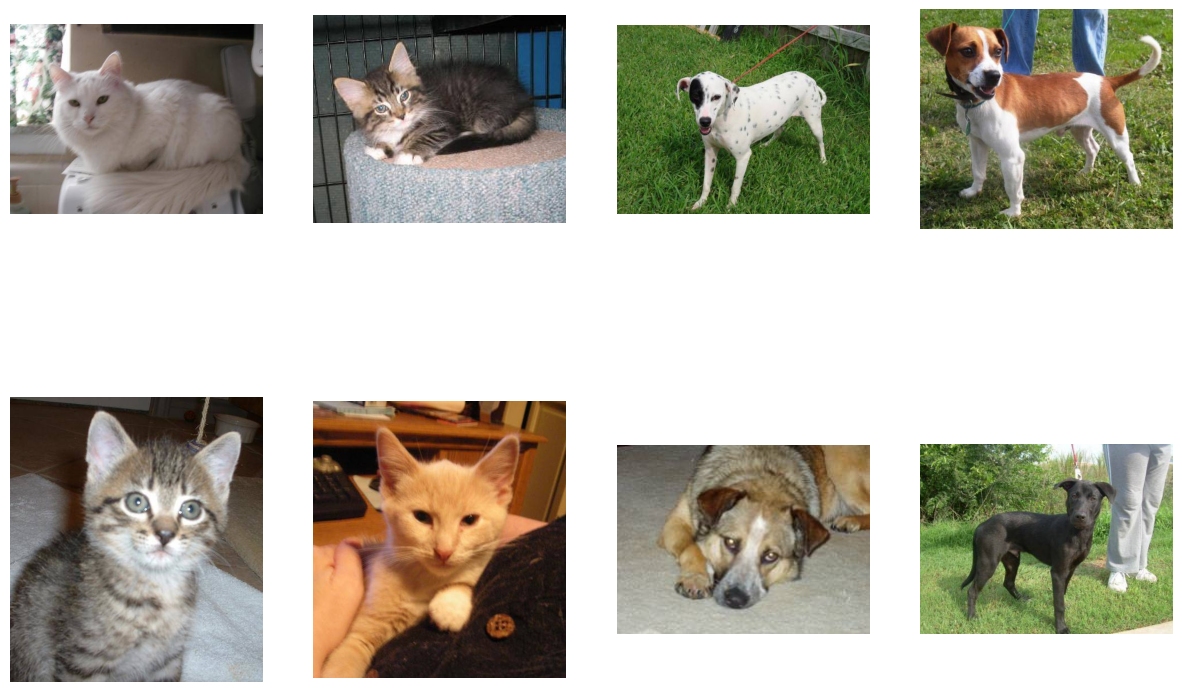

In [24]:
plt.figure(figsize=(15,10))
rand = random.sample(range(len(test_images)),8)
for i ,idx in enumerate(rand):
    img = cv2.imread(test_images[idx])
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

### **Custom data for test data**

In [25]:
class Animal_CnnTest(Dataset):
      def __init__(self,images,transforms= None):
          self.images = images
          self.transforms = transforms

      def __len__(self):
          return len(self.images)

      def __getitem__(self,idx):
          image = Image.open(self.images[idx]).convert('RGB')
          if self.transforms :
              image = self.transforms(image)

          return image

### **Transform test images**

In [26]:
# for test data
test_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        std = [0.229,0.224,0.225],
        mean = [0.485,0.456,0.406]
    )
])

### **Building test dataset**

In [27]:
# test_dataset
test_dataset = Animal_CnnTest(
    test_images,
    transforms = test_transforms
)

### **Test dataloader**

In [28]:
# test dataloader
test_loader = DataLoader(
    test_dataset ,
    batch_size = BZ ,
    shuffle = False)

## **Prediction**

In [29]:
predictions = []

Animal_CnnModel.eval()

with torch.no_grad():

    for images in test_loader:

        images = images.to(device)

        outputs = Animal_CnnModel(images)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

To visualize predicted images and labels:

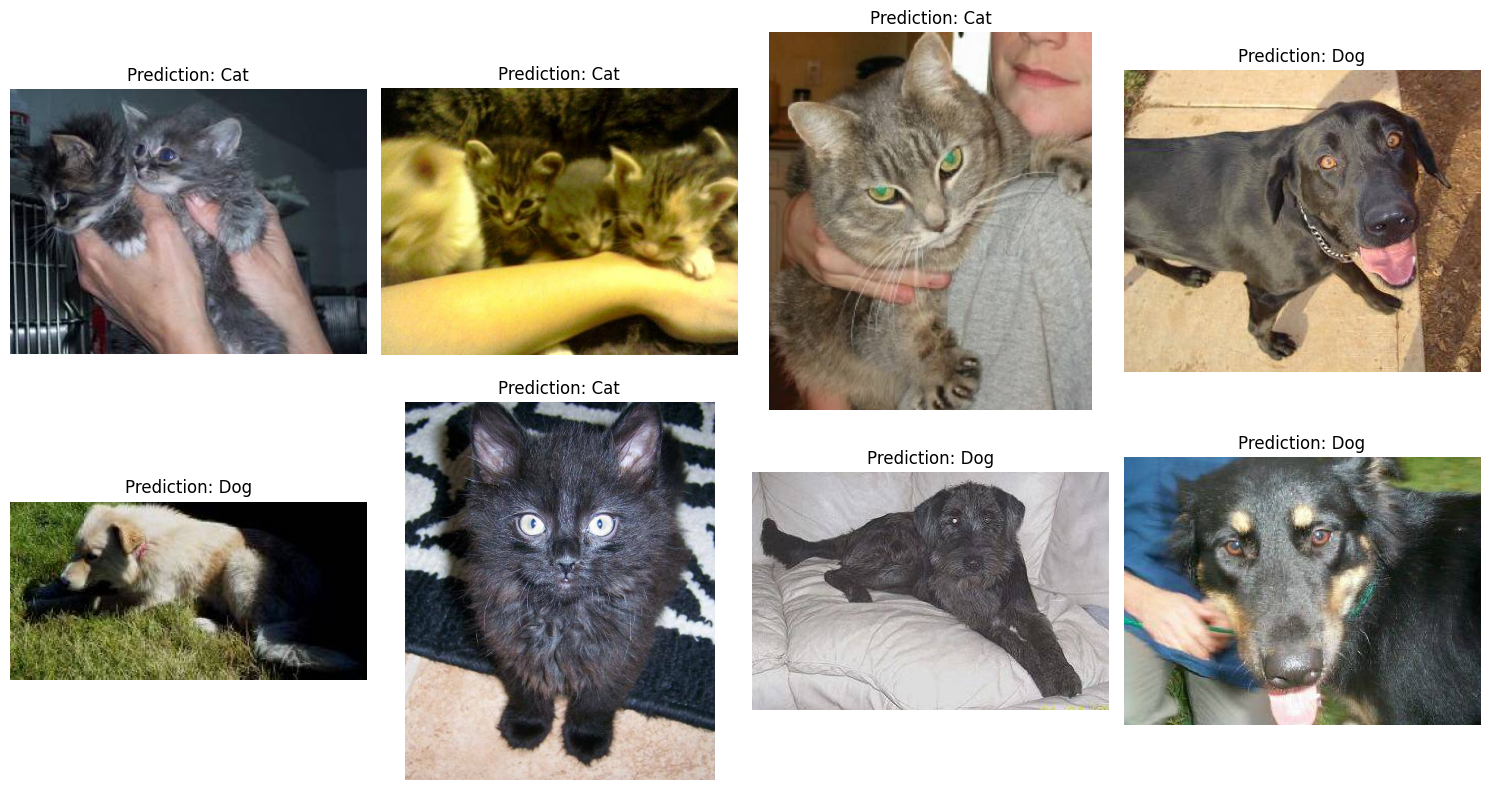

In [30]:
classes = ["Cat", "Dog"]

# random samples
random_idx = random.sample(range(len(test_images)), 8)

plt.figure(figsize=(15,8))

for i, idx in enumerate(random_idx):

    img = cv2.imread(test_images[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(f"Prediction: {classes[predictions[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()